In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
billings = pd.read_csv('../../data/raw/billings.csv', low_memory=False)
billings.shape

(122082, 59)

Drop duplicate rows

In [3]:
billings.duplicated().sum()

np.int64(0)

Drop rows with null `Co_Ref`

In [4]:
billings['Co_Ref'].isnull().sum()

np.int64(0)

Filter record with 'Open' as they dont have any outcome

In [5]:
print('Prospect_Outcome before filter:')
print(billings['Prospect_Outcome'].value_counts())

Prospect_Outcome before filter:
Prospect_Outcome
Won        101226
Churned     12668
Open         8188
Name: count, dtype: int64


In [6]:
billings = billings[billings['Prospect_Outcome'].isin(['Won', 'Churned'])].copy()
billings['Prospect_Outcome'].value_counts()

Prospect_Outcome
Won        101226
Churned     12668
Name: count, dtype: int64

Removing years after 2026 as they are outliers

In [7]:
billings['Renewal_Year'].value_counts().sort_index()

Renewal_Year
2023    33925
2024    34601
2025    36463
2026     8901
2027        2
2050        2
Name: count, dtype: int64

In [8]:
bad = billings[~billings['Renewal_Year'].isin([2023, 2024, 2025, 2026])]
print(f'\nRows with bad Renewal_Year: {len(bad)}')


Rows with bad Renewal_Year: 4


In [9]:
billings = billings[billings['Renewal_Year'].isin([2023, 2024, 2025, 2026])].copy()
billings.shape

(113890, 59)

Drop irrelevant columns

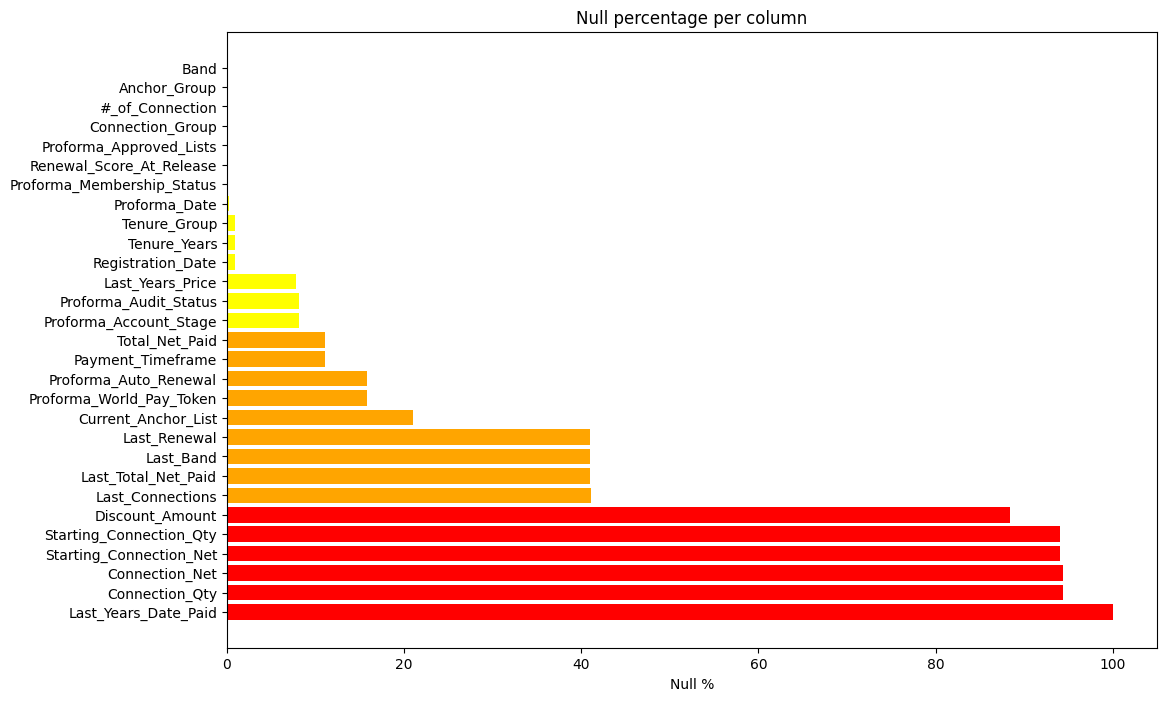

In [10]:
null_df = pd.DataFrame({
    'null_count': billings.isnull().sum(),
    'null_pct': billings.isnull().mean() * 100
}).sort_values('null_pct', ascending=False)

null_df = null_df[null_df['null_pct'] > 0]

plt.figure(figsize=(12,8))
colors = []

for val in null_df['null_pct']:
    if val > 50:
        colors.append('red')
    elif val > 10:
        colors.append('orange')
    else:
        colors.append('yellow')

plt.barh(null_df.index, null_df['null_pct'], color=colors)
plt.xlabel('Null %')
plt.title('Null percentage per column')
plt.show()

In [11]:
for col in ['Starting_Net', 'Gross', 'Membership_Net', 'PQQNet', 'Total_Amount']:
    r = billings[col].corr(billings['Amount'])
    print(f"  {col} vs Amount: r = {r:.3f}")

  Starting_Net vs Amount: r = 1.000
  Gross vs Amount: r = 0.966
  Membership_Net vs Amount: r = 0.936
  PQQNet vs Amount: r = 0.775
  Total_Amount vs Amount: r = 0.967


In [12]:
print((billings['Anchor_Group'] == billings['Connection_Group']).all())

False


In [13]:
mask = billings['Anchor_Group'] == billings['Connection_Group']
mismatch_rows = billings[~mask][['Anchor_Group', 'Connection_Group']]
print(mismatch_rows)

       Anchor_Group Connection_Group
46784           NaN              NaN
46785           NaN              NaN
46787           NaN              NaN
46789           NaN              NaN
59007           NaN              NaN
...             ...              ...
112259          NaN              NaN
114143          NaN              NaN
114239          NaN              NaN
114244          NaN              NaN
114248          NaN              NaN

[118 rows x 2 columns]


In [14]:
drop_cols = [
    # highly null cols
    'Last_Years_Date_Paid',
    'Connection_Net', 'Connection_Qty',
    'Starting_Connection_Net', 'Starting_Connection_Qty',
    'Discount_Amount',
    # Redundant price sub-components
    'Starting_Net', 'Starting_Vat', 'Starting_Gross',
    'Starting_Membership_Net', 'Starting_Package_Net', 'Starting_PQQ_Net',
    'Gross', 'Membership_Net', 'Package_Net', 'PQQNet',
    'Total_Amount',
    # Duplicate of Connection_Group
    'Anchor_Group',
    # Redundant date cols
    'Proforma_Date',
    'DateTime_Out',
]

billings = billings.drop(columns=drop_cols)
billings.shape

(113890, 39)

Converting datatype of date

In [15]:
date_cols = ['Prospect_Renewal_Date', 'Registration_Date', 'Closed_Date', 'Last_Renewal']
for col in date_cols:
    billings[col] = pd.to_datetime(billings[col], format='%d-%m-%Y', errors='coerce')

print('Date columns parsed. Null counts after parsing:')
print(billings[date_cols].isnull().sum())

Date columns parsed. Null counts after parsing:
Prospect_Renewal_Date        0
Registration_Date          975
Closed_Date                  0
Last_Renewal             46682
dtype: int64


Handle columns with bad / mixed values

1- Proforma_Account_Stage

In [16]:
billings['Proforma_Account_Stage'].value_counts(dropna=False)

Proforma_Account_Stage
Published          72409
Membership Only    16124
Renewal Process    12875
NaN                 9221
Vetting             2387
Suspended            871
Retired                2
vetting                1
Name: count, dtype: int64

In [17]:
valid_stages = ['Published', 'Membership Only', 'Renewal Process', 'Vetting', 'Suspended', 'Retired']
mode_val = billings['Proforma_Account_Stage'].mode()[0]
billings['Proforma_Account_Stage'] = billings['Proforma_Account_Stage'].where(billings['Proforma_Account_Stage'].isin(valid_stages), other=mode_val)
billings['Proforma_Account_Stage'] = billings['Proforma_Account_Stage'].fillna(mode_val)
billings['Proforma_Account_Stage'].value_counts()

Proforma_Account_Stage
Published          81631
Membership Only    16124
Renewal Process    12875
Vetting             2387
Suspended            871
Retired                2
Name: count, dtype: int64

2- Proforma_Membership_Status

In [18]:
billings['Proforma_Membership_Status'].value_counts(dropna=False)

Proforma_Membership_Status
Accredited     84116
Member Only    18916
In Progress    10737
NaN              118
Non Member         3
Name: count, dtype: int64

In [19]:
billings = billings.dropna(subset=['Proforma_Membership_Status'])
billings['Proforma_Membership_Status'].value_counts(dropna=False)

Proforma_Membership_Status
Accredited     84116
Member Only    18916
In Progress    10737
Non Member         3
Name: count, dtype: int64

3- Proforma_Audit_Status<br>
Mapping and replacing values

In [20]:
billings['Proforma_Audit_Status'].value_counts().head()

Proforma_Audit_Status
Accredited                                             71377
Failed- Renewal Questionnaire not received              6080
Renewal Questionnaire Received                          5992
Failed- Renewal Additional Information Not Received     3549
Failed- Initial additional info not received            3399
Name: count, dtype: int64

In [21]:
mapping = {
    # Accredited
    'Accredited':                                                   'Accredited',
    'Accredited - SSiP due to expire':                              'Accredited',
    'Accred Due to Expire':                                         'Accredited',
    # In Process
    'Renewal Questionnaire Received':                               'In Process',
    'Renewal Questionnaire Sent':                                   'In Process',
    'Renewal report sent - Awaiting information':                   'In Process',
    '1st Renewal questionnaire reminder':                           'In Process',
    'Final renewal questionnaire reminder':                         'In Process',
    '1st Reminder - Renewal additional info':                       'In Process',
    'Final reminder - Renewal additional info':                     'In Process',
    'Renewal additional information received':                      'In Process',
    'Initial Questionnaire Received':                               'In Process',
    'Initial Questionnaire Sent':                                   'In Process',
    '1st reminder initial add info':                                'In Process',
    'Final Reminder (Initial) Additional Information Not Sent':     'In Process',
    'Report sent - Awaiting information':                           'In Process',
    'Additional information received':                              'In Process',
    'Initial - 1st Questionnaire reminder sent':                    'In Process',
    'Accredited - SSiP due to expire':                              'Accredited',
    # Failed
    'Failed- Renewal Questionnaire not received':                   'Failed',
    'Failed- Renewal Additional Information Not Received':          'Failed',
    'Failed- Initial additional info not received':                 'Failed',
    'Failed- Initial Questionnaire not received':                   'Failed',
    'Failed- Accreditation removed SSiP exp':                       'Failed',
    # Suspended
    'SUSPENDED - SSiP Expired':                                     'Suspended',
    'SUSPENDED - 1st reminder SSiP Expired':                        'Suspended',
    'SUSPENDED - 2nd reminder SSiP Expired':                        'Suspended',
    'SSiP Expired - 1st Reminder':                                  'Suspended',
    'Suspended - Insurance Out-of-Date':                            'Suspended',
    'Withdrawn from scheme':                                        'Suspended',
}

billings['Proforma_Audit_Status'] = billings['Proforma_Audit_Status'].map(mapping).fillna('In Process')
billings['Proforma_Audit_Status'].value_counts()

Proforma_Audit_Status
Accredited    72407
In Process    24367
Failed        16125
Suspended       873
Name: count, dtype: int64

4- Connection_Group<br>
Mixed int and string types (`1` and `'1'` both exist). Standardise to string.

In [22]:
billings['Connection_Group'].value_counts()

Connection_Group
1              35435
Independent    23118
4 to 9         19435
2              18167
3               9830
10+             7787
Name: count, dtype: int64

In [23]:
billings['Connection_Group'] = billings['Connection_Group'].astype(str)

valid_conn = ['Independent', '1', '2', '3', '4 to 9', '10+']
mode_conn = billings['Connection_Group'].mode()[0]
billings['Connection_Group'] = billings['Connection_Group'].where(
    billings['Connection_Group'].isin(valid_conn), other=mode_conn
)
billings['Connection_Group'].value_counts()

Connection_Group
1              35435
Independent    23118
4 to 9         19435
2              18167
3               9830
10+             7787
Name: count, dtype: int64

5-Band

In [24]:
billings['Band'].value_counts(dropna=False)

Band
Band B     30470
Band C1    23155
Band D     17707
Band C2    14728
Band E      8995
Band F1     5425
Band A      3521
Band F2     2934
Band G      2234
Band F      2188
Group        923
Band H       767
Band I       362
Band J       357
NaN            6
Name: count, dtype: int64

In [25]:
billings = billings.dropna(subset=['Band'])
billings['Band'].value_counts(dropna=False)

Band
Band B     30470
Band C1    23155
Band D     17707
Band C2    14728
Band E      8995
Band F1     5425
Band A      3521
Band F2     2934
Band G      2234
Band F      2188
Group        923
Band H       767
Band I       362
Band J       357
Name: count, dtype: int64

Last_Band / Last_Years_Price / Last_Connections<br>
These are null for **new customers** (first-ever renewal — no prior year exists).
This is **structural** missingness, not a data error.

In [26]:
print('Last_Band nulls:', billings['Last_Band'].isnull().sum())
print('Last_Years_Price nulls:', billings['Last_Years_Price'].isnull().sum())
print('Last_Connections nulls:', billings['Last_Connections'].isnull().sum())

# fill with 0 for new customers
billings['Last_Years_Price'] = billings['Last_Years_Price'].fillna(0)
if 'Last_Connections' in billings.columns:
    billings['Last_Connections'] = billings['Last_Connections'].fillna(0)
# fill with 'New Customer' category
billings['Last_Band'] = billings['Last_Band'].fillna('New Customer')

print('Last_Years_Price nulls:', billings['Last_Years_Price'].isnull().sum())
print('Last_Band nulls:', billings['Last_Band'].isnull().sum())

Last_Band nulls: 46632
Last_Years_Price nulls: 8805
Last_Connections nulls: 46690
Last_Years_Price nulls: 0
Last_Band nulls: 0


Tenure_Years<br>
Small number of nulls (~1%). Fill with median tenure.

In [27]:
print('Tenure_Years nulls before:', billings['Tenure_Years'].isnull().sum())
print('Tenure_Years stats:\n', billings['Tenure_Years'].describe().round(2))

# Cap extreme values at 30
billings['Tenure_Years'] = billings['Tenure_Years'].clip(upper=30)

median_tenure = billings['Tenure_Years'].median()
print(f'\nMedian tenure used for imputation: {median_tenure}')
billings['Tenure_Years'] = billings['Tenure_Years'].fillna(median_tenure)

print('Tenure_Years nulls after :', billings['Tenure_Years'].isnull().sum())

Tenure_Years nulls before: 972
Tenure_Years stats:
 count    112794.00
mean          6.86
std           5.39
min           0.00
25%           2.00
50%           5.00
75%          10.00
max          26.00
Name: Tenure_Years, dtype: float64

Median tenure used for imputation: 5.0
Tenure_Years nulls after : 0


Categorical Columns: Fill nulls with 'Unknown'

In [28]:
cat_cols = [
    'Tenure_Group',
    'Registration_Date'
]

for col in cat_cols:
    before = billings[col].isnull().sum()
    billings[col] = billings[col].fillna('Unknown')
    print(f'{col}: {before} nulls → filled with "Unknown"')

Tenure_Group: 972 nulls → filled with "Unknown"
Registration_Date: 972 nulls → filled with "Unknown"


Numeric Columns: Fill with 0 or Median

In [29]:
# fill with 0 (no connections = independent)
print('#_of_Connection nulls before:', billings['#_of_Connection'].isnull().sum())
billings['#_of_Connection'] = billings['#_of_Connection'].fillna(0)
print('#_of_Connection nulls after :', billings['#_of_Connection'].isnull().sum())

#_of_Connection nulls before: 0
#_of_Connection nulls after : 0


In [30]:
# fill with median
if 'Renewal_Score_At_Release' in billings.columns:
    med = billings['Renewal_Score_At_Release'].median()
    print(f'\nRenewal_Score_At_Release nulls before: {billings["Renewal_Score_At_Release"].isnull().sum()}')
    billings['Renewal_Score_At_Release'] = billings['Renewal_Score_At_Release'].fillna(med)
    print(f'Renewal_Score_At_Release nulls after : {billings["Renewal_Score_At_Release"].isnull().sum()}')


Renewal_Score_At_Release nulls before: 0
Renewal_Score_At_Release nulls after : 0


In [31]:
# fill with 0 (0 = paid on time)
if 'Payment_Timeframe' in billings.columns:
    print(f'\nPayment_Timeframe nulls before: {billings["Payment_Timeframe"].isnull().sum()}')
    billings['Payment_Timeframe'] = billings['Payment_Timeframe'].fillna(0)
    print(f'Payment_Timeframe nulls after : {billings["Payment_Timeframe"].isnull().sum()}')



Payment_Timeframe nulls before: 12592
Payment_Timeframe nulls after : 0


In [32]:
# fill with Amount (if not paid fill with asked amount)
if 'Total_Net_Paid' in billings.columns:
    print(f'\nTotal_Net_Paid nulls before: {billings["Total_Net_Paid"].isnull().sum()}')
    billings['Total_Net_Paid'] = billings['Total_Net_Paid'].fillna(billings['Amount'])
    print(f'Total_Net_Paid nulls after : {billings["Total_Net_Paid"].isnull().sum()}')


Total_Net_Paid nulls before: 12592
Total_Net_Paid nulls after : 0


In [33]:
remaining_nulls = billings.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print('Remaining nulls after all imputation:')
print(remaining_nulls.to_string())

Remaining nulls after all imputation:
Proforma_Auto_Renewal       17924
Proforma_World_Pay_Token    17924
Current_Anchor_List         23932
Last_Renewal                46616
Last_Total_Net_Paid         46664


In [34]:
cols_to_drop = [
    'Proforma_Auto_Renewal',      # redundant with auto_renewal (engineered)
    'Proforma_World_Pay_Token',   # redundant with has_worldpay_token (engineered)
    'Current_Anchor_List',        # text list of client names — not a model feature
    'Last_Renewal',               # date column, not in final feature list
    'Last_Total_Net_Paid',        # 41% null, Last_Years_Price already covers prior pricing
]
cols_to_drop = [c for c in cols_to_drop if c in billings.columns]
billings.drop(columns=cols_to_drop, inplace=True)

# fill with median
med_approved = billings['Proforma_Approved_Lists'].median()
billings['Proforma_Approved_Lists'] = billings['Proforma_Approved_Lists'].fillna(med_approved)
if 'days_as_member' in billings.columns:
    med_days = billings['days_as_member'].median() 
    billings['days_as_member'] = billings['days_as_member'].fillna(med_days)

In [35]:
remaining_nulls = billings.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print('Remaining nulls after all imputation:')
if len(remaining_nulls) == 0:
    print('  None — all nulls handled!')
else:
    print(remaining_nulls.to_string())

Remaining nulls after all imputation:
  None — all nulls handled!


In [36]:
billings.columns = billings.columns.str.lower().str.replace(' ', '_')

In [37]:
billings = billings.sort_values(by=["co_ref", "renewal_year"]).reset_index(drop=True)

# drop old incorrect column and recompute from total_net paid
billings = billings.drop(columns=["last_years_price"], errors="ignore")
billings["last_years_price"] = (billings.groupby("co_ref")["total_net_paid"].shift(1))

# handle first year
billings["last_years_price"] = billings["last_years_price"].fillna(0)
billings["price_change"] = billings["total_net_paid"] - billings["last_years_price"]


Save cleaned dataset

In [38]:
import os
os.makedirs('../../data/cleaned', exist_ok=True)
billings.to_csv('../../data/cleaned/billings_cleaned.csv', index=False)